## Principal Component Analysis (PCA) for Dimensionality Reduction

### Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

### Load Data

In [2]:
# Load data from dataset_generators/datasets
final_df_with_lags = pd.read_csv('../dataset_generators/datasets/final_1_lag_ffa_dataset.csv')

### Load PCA

In [3]:
with open('../model_generators/pca/models/pca_model.pkl', 'rb') as f:
    pca = pickle.load(f)

### PCA Visualization

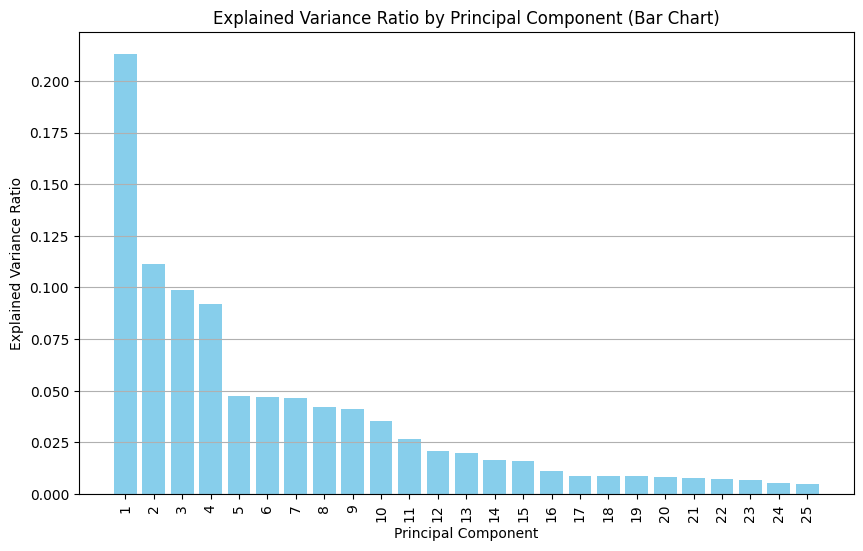

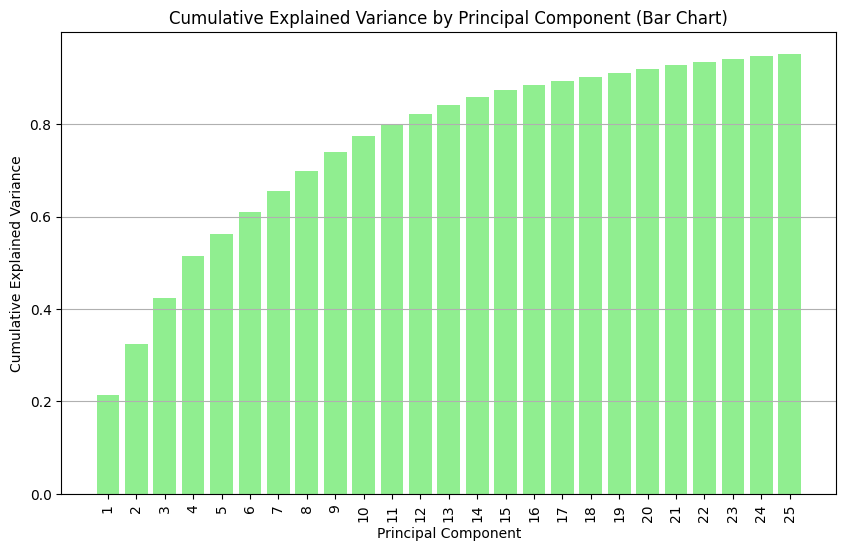

In [4]:
# function plot PcA explained variance
def plot_explained_variance(pca):
    # Bar chart for explained variance ratio of each principal component
    plt.figure(figsize=(10,6))
    plt.bar(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, color='skyblue')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Explained Variance Ratio by Principal Component (Bar Chart)')
    plt.xticks(np.arange(1, len(pca.explained_variance_ratio_)+1), rotation=90)
    plt.grid(axis='y')
    plt.show()

    # Bar chart for cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10,6))
    plt.bar(np.arange(1, len(cumulative_variance)+1), cumulative_variance, color='lightgreen')
    plt.xlabel('Principal Component')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance by Principal Component (Bar Chart)')
    plt.xticks(np.arange(1, len(cumulative_variance)+1), rotation=90)
    plt.grid(axis='y')
    plt.show()
    
plot_explained_variance(pca)

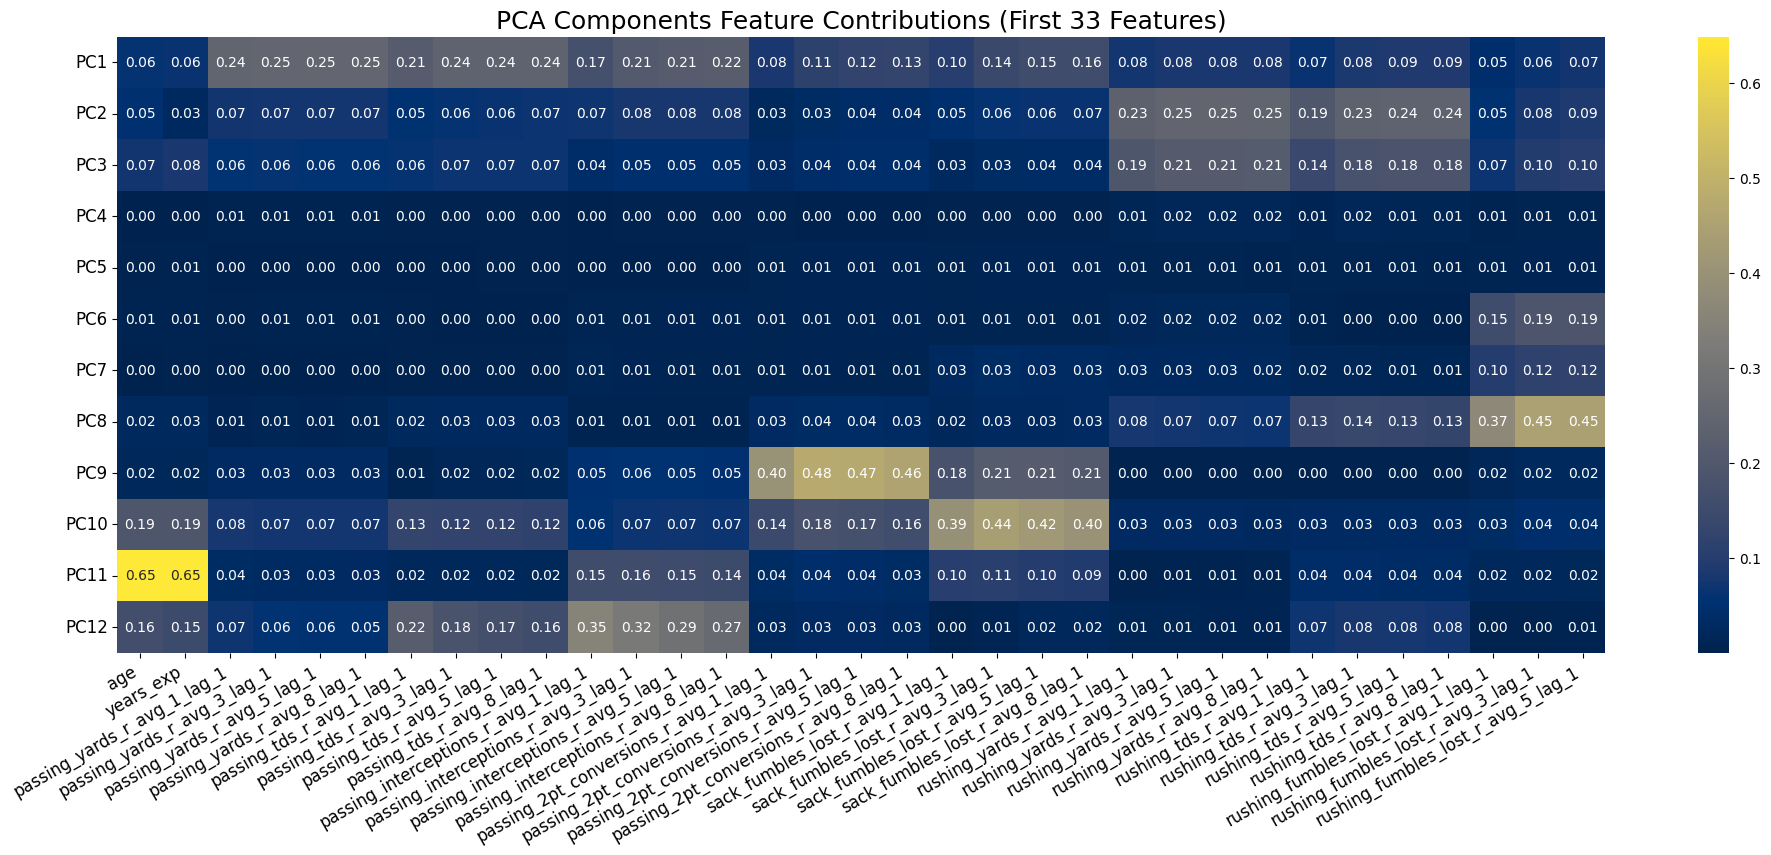

In [5]:
# Function to plot PCA components(first 33 columns)
def plot_pca_components(pca, feature_names):
    pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
    
    # Create a DataFrame for the PCA components
    pca_components = pd.DataFrame(pca.components_[:12], columns=feature_names, index=pca_columns[:12])
    
    # absolute values of components for better visualization
    pca_components = pca_components.abs()
    
    # Plot the PCA components
    plt.figure(figsize=(24, 8))
    sns.heatmap(pca_components.iloc[:, :33], cmap='cividis', annot=True, fmt=".2f")
    plt.title("PCA Components Feature Contributions (First 33 Features)", fontsize=18)
    plt.xticks(rotation=30, ha='right', fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    # plt.xlabel("Features", fontsize=14)
    # plt.ylabel("Principal Components (First 12)", fontsize=14)
    plt.savefig("../model_visualizations/pca/pca_feature_contributions_1.png")
    plt.show()
    
plot_pca_components(pca, final_df_with_lags.columns[11:].drop('fantasy_points'))

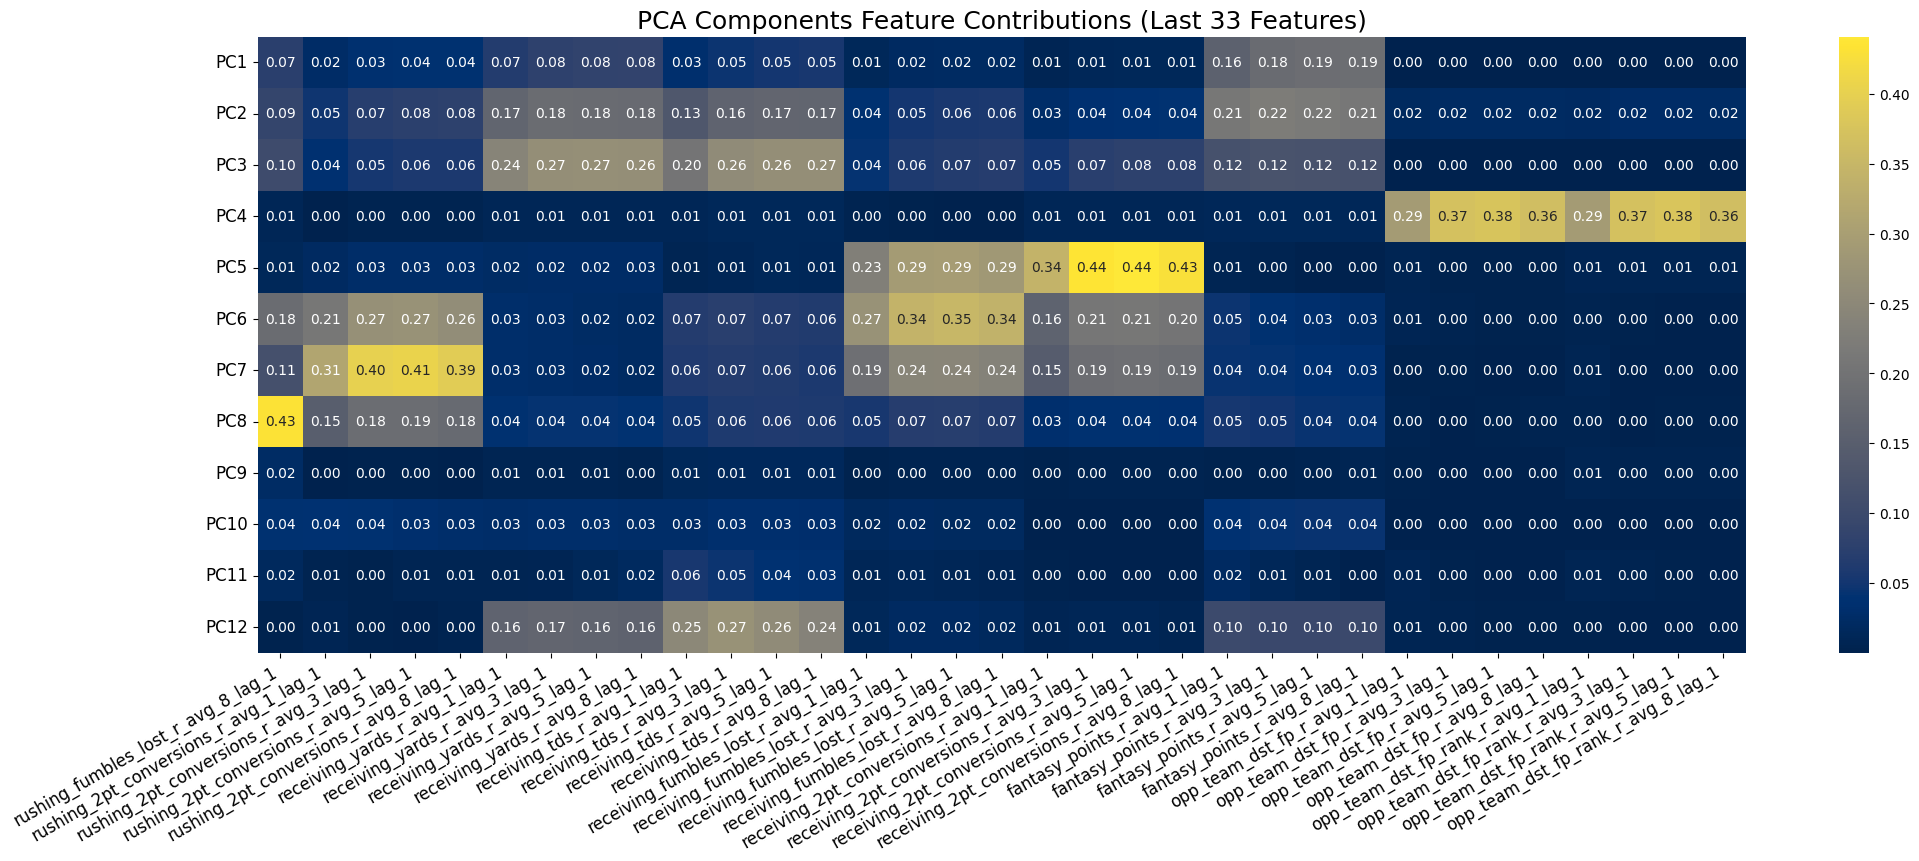

In [6]:
# Function to plot PCA components (last 33 columns)
def plot_pca_components(pca, feature_names):
    pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
    
    # Create a DataFrame for the PCA components
    pca_components = pd.DataFrame(pca.components_[:12], columns=feature_names, index=pca_columns[:12])
    
    # Absolute values of components for better visualization
    pca_components = pca_components.abs()
    
    # Plot the PCA components
    plt.figure(figsize=(24, 8))
    sns.heatmap(pca_components.iloc[:, -33:], cmap='cividis', annot=True, fmt=".2f")
    plt.title("PCA Components Feature Contributions (Last 33 Features)", fontsize=18)
    plt.xticks(rotation=30, ha='right', fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    # plt.xlabel("Features", fontsize=14)
    # plt.ylabel("Principal Components (First 12)", fontsize=14)
    plt.savefig("../model_visualizations/pca/pca_feature_contributions_2.png")
    plt.show()
    
plot_pca_components(pca, final_df_with_lags.columns[11:].drop('fantasy_points'))

### PCA

In [7]:
# Function to extract PCA features
def extract_pca_features(pca):
    # export pca data to csv
    # pca_df = pd.DataFrame(pca.components_)
    # pca_df.to_csv('pca_components.csv', index=False)
    
    # Use the feature names from the original DataFrame columns
    feature_names = [col for col in final_df_with_lags.columns[11:] if col != 'fantasy_points']
    pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
    pca_features = pd.DataFrame(pca.components_, columns=feature_names, index=pca_columns)
    return pca_features

pca_features = extract_pca_features(pca)

In [8]:
pca_features

,age,years_exp,passing_yards_r_avg_1_lag_1,passing_yards_r_avg_3_lag_1,passing_yards_r_avg_5_lag_1,passing_yards_r_avg_8_lag_1,passing_tds_r_avg_1_lag_1,passing_tds_r_avg_3_lag_1,passing_tds_r_avg_5_lag_1,passing_tds_r_avg_8_lag_1,...,fantasy_points_r_avg_5_lag_1,fantasy_points_r_avg_8_lag_1,opp_team_dst_fp_r_avg_1_lag_1,opp_team_dst_fp_r_avg_3_lag_1,opp_team_dst_fp_r_avg_5_lag_1,opp_team_dst_fp_r_avg_8_lag_1,opp_team_dst_fp_rank_r_avg_1_lag_1,opp_team_dst_fp_rank_r_avg_3_lag_1,opp_team_dst_fp_rank_r_avg_5_lag_1,opp_team_dst_fp_rank_r_avg_8_lag_1
PC1,0.061572,0.064572,0.243954,0.249289,0.249662,0.249371,0.213118,0.235714,0.239059,0.240048,...,0.187354,0.189033,0.000149,0.000678,-0.000186,-0.000326,-0.000866,-0.001082,-0.000233,-0.000014
PC2,-0.048560,-0.025976,-0.071601,-0.073975,-0.074417,-0.074639,-0.054718,-0.063122,-0.064955,-0.066224,...,0.216779,0.210308,0.018002,0.021909,0.022272,0.021451,-0.020619,-0.024298,-0.024336,-0.023252
PC3,0.073352,0.081951,0.060448,0.060909,0.060772,0.060638,0.062702,0.066465,0.066480,0.066340,...,0.120099,0.118340,-0.000986,0.000121,-0.000270,-0.000033,-0.000474,-0.001085,-0.000298,0.000126
PC4,-0.001713,-0.001356,-0.005628,-0.005987,-0.006098,-0.006178,-0.003521,-0.004181,-0.004470,-0.004703,...,0.012155,0.011554,-0.291537,-0.370956,-0.376988,-0.364639,0.291717,0.370793,0.377545,0.364514
PC5,-0.004327,-0.005498,-0.002000,-0.002197,-0.002149,-0.002130,-0.001858,-0.002336,-0.002559,-0.002687,...,0.001678,-0.000192,0.005256,0.002466,0.002351,0.002443,-0.007731,-0.005601,-0.005601,-0.005981
PC6,-0.005422,-0.007325,0.004647,0.005601,0.006161,0.006091,-0.003919,-0.000425,0.000028,0.000566,...,-0.031282,-0.027299,0.007227,0.004436,0.003205,0.002321,-0.003685,-0.002507,-0.001197,-0.000021
PC7,-0.000842,-0.002732,0.000432,-0.000021,-0.000341,-0.000241,-0.002891,-0.004901,-0.004385,-0.004225,...,-0.037970,-0.034869,0.003129,-0.002254,-0.001124,-0.000819,-0.006221,0.000572,0.000128,0.000355
PC8,-0.024552,-0.025187,-0.012166,-0.012735,-0.012396,-0.012752,-0.024952,-0.026054,-0.025868,-0.025411,...,-0.044417,-0.042139,0.003672,0.001684,0.002675,0.003779,-0.003615,-0.000873,-0.001846,-0.003012
PC9,-0.021722,-0.018269,-0.028683,-0.030206,-0.030112,-0.030006,-0.009997,-0.015415,-0.016741,-0.017960,...,-0.004465,-0.005615,0.002923,-0.000002,-0.000009,-0.000417,-0.005361,-0.003954,-0.004049,-0.003910
PC10,-0.191113,-0.191647,-0.076850,-0.074888,-0.073934,-0.073855,-0.125450,-0.124062,-0.122383,-0.118209,...,-0.043218,-0.044511,0.000990,0.000981,0.001656,0.000251,-0.000208,-0.000446,-0.001160,0.000234


In [9]:
# Find 3 max values for each principal component and format them nicely
max_contributing_features_df = pd.DataFrame()

for pc in pca_features.index:
    # Get absolute values and find top 4 features
    top_4_features = pca_features.loc[pc].abs().nlargest(4)
    
    # Create a series with feature names and their values
    feature_series = pd.Series({
        'PC': pc,
        'Top_1': f"{top_4_features.index[0]} ({top_4_features.values[0]:.3f})",
        'Top_2': f"{top_4_features.index[1]} ({top_4_features.values[1]:.3f})",
        'Top_3': f"{top_4_features.index[2]} ({top_4_features.values[2]:.3f})",
        'Top_4': f"{top_4_features.index[3]} ({top_4_features.values[3]:.3f})",
        'Explained_Variance_Ratio': f"{pca_features.loc[pc].abs().sum():.3f}"
    })
    
    max_contributing_features_df = pd.concat([max_contributing_features_df, feature_series.to_frame().T], ignore_index=True)

max_contributing_features_df.set_index('PC', inplace=True)
max_contributing_features_df


,Top_1,Top_2,Top_3,Top_4,Explained_Variance_Ratio
PC,,,,,
PC1,passing_yards_r_avg_5_lag_1 (0.250),passing_yards_r_avg_8_lag_1 (0.249),passing_yards_r_avg_3_lag_1 (0.249),passing_yards_r_avg_1_lag_1 (0.244),6.222
PC2,rushing_yards_r_avg_3_lag_1 (0.248),rushing_yards_r_avg_5_lag_1 (0.248),rushing_yards_r_avg_8_lag_1 (0.246),rushing_tds_r_avg_5_lag_1 (0.239),6.477
PC3,receiving_yards_r_avg_5_lag_1 (0.266),receiving_yards_r_avg_3_lag_1 (0.265),receiving_tds_r_avg_8_lag_1 (0.265),receiving_tds_r_avg_5_lag_1 (0.265),6.213
PC4,opp_team_dst_fp_rank_r_avg_5_lag_1 (0.378),opp_team_dst_fp_r_avg_5_lag_1 (0.377),opp_team_dst_fp_r_avg_3_lag_1 (0.371),opp_team_dst_fp_rank_r_avg_3_lag_1 (0.371),3.235
PC5,receiving_2pt_conversions_r_avg_5_lag_1 (0.441),receiving_2pt_conversions_r_avg_3_lag_1 (0.436),receiving_2pt_conversions_r_avg_8_lag_1 (0.428),receiving_2pt_conversions_r_avg_1_lag_1 (0.344),3.268
PC6,receiving_fumbles_lost_r_avg_5_lag_1 (0.350),receiving_fumbles_lost_r_avg_3_lag_1 (0.344),receiving_fumbles_lost_r_avg_8_lag_1 (0.340),receiving_fumbles_lost_r_avg_1_lag_1 (0.271),4.594
PC7,rushing_2pt_conversions_r_avg_5_lag_1 (0.405),rushing_2pt_conversions_r_avg_3_lag_1 (0.401),rushing_2pt_conversions_r_avg_8_lag_1 (0.393),rushing_2pt_conversions_r_avg_1_lag_1 (0.315),4.503
PC8,rushing_fumbles_lost_r_avg_3_lag_1 (0.450),rushing_fumbles_lost_r_avg_5_lag_1 (0.447),rushing_fumbles_lost_r_avg_8_lag_1 (0.432),rushing_fumbles_lost_r_avg_1_lag_1 (0.369),4.677
PC9,passing_2pt_conversions_r_avg_3_lag_1 (0.478),passing_2pt_conversions_r_avg_5_lag_1 (0.472),passing_2pt_conversions_r_avg_8_lag_1 (0.455),passing_2pt_conversions_r_avg_1_lag_1 (0.399),3.303


In [10]:
# Function to rename index to reflect top contributing feature
def rename_pca_index(max_contributing_features_df, pca_features):
    # Create a mapping of old index to new index based on the top contributing feature
    index_mapping = {}
    used_names = set()

    for pc in max_contributing_features_df.index:
        # Loop through all top contributing features for the principal component
        for rank in ['Top_1', 'Top_2', 'Top_3', 'Top_4']:
            top_feature = max_contributing_features_df.loc[pc, rank].split(' ')[0]
            if top_feature not in used_names:
                used_names.add(top_feature)
                new_name = f"PC_{top_feature}"
                # Be sure to remove last 14 characters from each entry here except 'age' and 'years_exp' before checking uniqueness
                if new_name.endswith('_age') or new_name.endswith('_years_exp'):
                    pass
                else:
                    new_name = new_name[:-14]
                index_mapping[pc] = new_name
                break

    # Rename the index using the mapping
    max_contributing_features_df.rename(index=index_mapping, inplace=True)
    
    # Simply add number suffixes to duplicates
    final_index = []
    name_count = {}

    for name in max_contributing_features_df.index:
        if name in name_count:
            name_count[name] += 1
            new_name = f"{name}_{name_count[name]}"
            final_index.append(new_name)
        else:
            name_count[name] = 1
            final_index.append(name)

    max_contributing_features_df.index = final_index

    return max_contributing_features_df

# Apply the function to rename the index
renamed_pca_features = rename_pca_index(max_contributing_features_df, pca_features)
renamed_pca_features

,Top_1,Top_2,Top_3,Top_4,Explained_Variance_Ratio
PC_passing_yards,passing_yards_r_avg_5_lag_1 (0.250),passing_yards_r_avg_8_lag_1 (0.249),passing_yards_r_avg_3_lag_1 (0.249),passing_yards_r_avg_1_lag_1 (0.244),6.222
PC_rushing_yards,rushing_yards_r_avg_3_lag_1 (0.248),rushing_yards_r_avg_5_lag_1 (0.248),rushing_yards_r_avg_8_lag_1 (0.246),rushing_tds_r_avg_5_lag_1 (0.239),6.477
PC_receiving_yards,receiving_yards_r_avg_5_lag_1 (0.266),receiving_yards_r_avg_3_lag_1 (0.265),receiving_tds_r_avg_8_lag_1 (0.265),receiving_tds_r_avg_5_lag_1 (0.265),6.213
PC_opp_team_dst_fp_rank,opp_team_dst_fp_rank_r_avg_5_lag_1 (0.378),opp_team_dst_fp_r_avg_5_lag_1 (0.377),opp_team_dst_fp_r_avg_3_lag_1 (0.371),opp_team_dst_fp_rank_r_avg_3_lag_1 (0.371),3.235
PC_receiving_2pt_conversions,receiving_2pt_conversions_r_avg_5_lag_1 (0.441),receiving_2pt_conversions_r_avg_3_lag_1 (0.436),receiving_2pt_conversions_r_avg_8_lag_1 (0.428),receiving_2pt_conversions_r_avg_1_lag_1 (0.344),3.268
PC_receiving_fumbles_lost,receiving_fumbles_lost_r_avg_5_lag_1 (0.350),receiving_fumbles_lost_r_avg_3_lag_1 (0.344),receiving_fumbles_lost_r_avg_8_lag_1 (0.340),receiving_fumbles_lost_r_avg_1_lag_1 (0.271),4.594
PC_rushing_2pt_conversions,rushing_2pt_conversions_r_avg_5_lag_1 (0.405),rushing_2pt_conversions_r_avg_3_lag_1 (0.401),rushing_2pt_conversions_r_avg_8_lag_1 (0.393),rushing_2pt_conversions_r_avg_1_lag_1 (0.315),4.503
PC_rushing_fumbles_lost,rushing_fumbles_lost_r_avg_3_lag_1 (0.450),rushing_fumbles_lost_r_avg_5_lag_1 (0.447),rushing_fumbles_lost_r_avg_8_lag_1 (0.432),rushing_fumbles_lost_r_avg_1_lag_1 (0.369),4.677
PC_passing_2pt_conversions,passing_2pt_conversions_r_avg_3_lag_1 (0.478),passing_2pt_conversions_r_avg_5_lag_1 (0.472),passing_2pt_conversions_r_avg_8_lag_1 (0.455),passing_2pt_conversions_r_avg_1_lag_1 (0.399),3.303
PC_sack_fumbles_lost,sack_fumbles_lost_r_avg_3_lag_1 (0.439),sack_fumbles_lost_r_avg_5_lag_1 (0.423),sack_fumbles_lost_r_avg_8_lag_1 (0.402),sack_fumbles_lost_r_avg_1_lag_1 (0.393),4.756
